# AWS Cost Transformer Forecast — Treinamento e Avaliação

Demonstração ponta a ponta: geração da série sintética de custo AWS, treinamento do `TimeSeriesTransformer` (implementado do zero, com Positional Encoding manual) e avaliação das previsões no conjunto de teste.

Todos os módulos usados aqui vêm de `src/aws_cost_forecast/` — nenhuma lógica é duplicada neste notebook, só orquestração e visualização.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import MinMaxScaler

from aws_cost_forecast.data.synthetic_aws_cost import generate_synthetic_aws_cost
from aws_cost_forecast.model.transformer import TimeSeriesTransformer
from aws_cost_forecast.training.train import (
    build_dataloaders,
    collect_predictions,
    create_sequences,
    evaluate,
    select_device,
    sequences_to_tensors,
    train_one_epoch,
)

plt.rcParams["figure.dpi"] = 100

## 1. Gerando a série sintética de custo AWS

Sem dado real de cliente — a série combina tendência de crescimento, sazonalidade semanal/mensal, degraus de Savings Plans/RI, anomalias pontuais e ruído de cauda pesada (`src/aws_cost_forecast/data/synthetic_aws_cost.py`).

In [2]:
df = generate_synthetic_aws_cost(n_days=730, seed=42)
df.head()

,date,cost,is_anomaly
0,2023-01-01,3830.034424,False
1,2023-01-02,5199.387695,False
2,2023-01-03,5000.649414,False
3,2023-01-04,5175.443359,False
4,2023-01-05,5161.590820,False


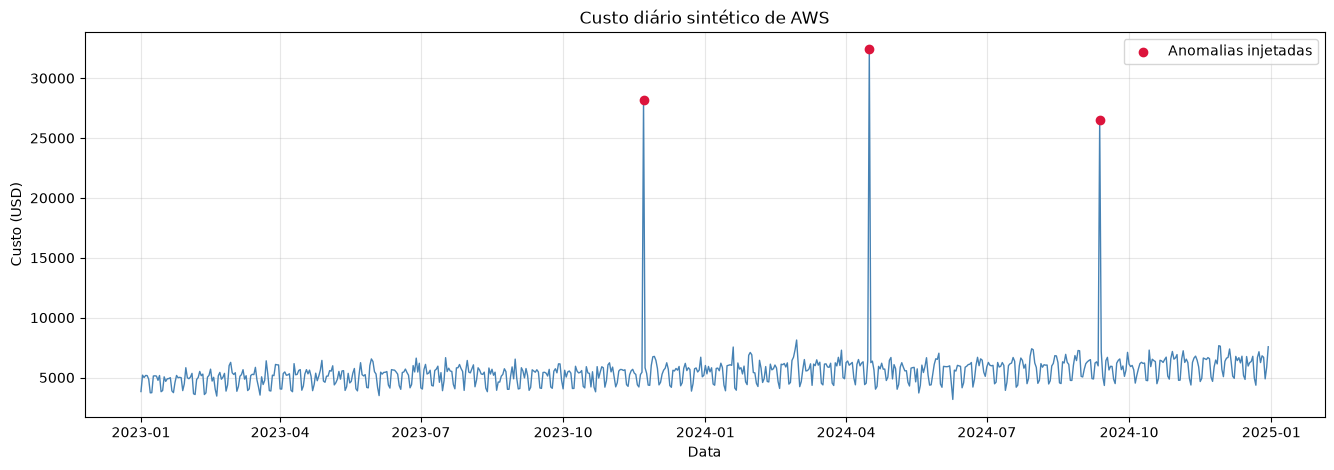

In [3]:
plt.figure(figsize=(16, 5))
plt.plot(df["date"], df["cost"], color="steelblue", linewidth=1)
plt.scatter(
    df.loc[df["is_anomaly"], "date"],
    df.loc[df["is_anomaly"], "cost"],
    color="crimson",
    label="Anomalias injetadas",
    zorder=5,
)
plt.title("Custo diário sintético de AWS")
plt.xlabel("Data")
plt.ylabel("Custo (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. Split treino/teste e normalização

O `MinMaxScaler` é ajustado **somente nos dados de treino** — usar min/max da série completa vazaria a distribuição do período de teste para dentro do treino.

In [4]:
device = select_device()
print(f"Usando dispositivo: {device}")

input_window = 50
train_split = 0.8
batch_size = 32

series = df["cost"].to_numpy().reshape(-1, 1)
cutoff = int(len(series) * train_split)
series_train, series_test = series[:cutoff], series[cutoff:]

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(series_train)
series_train_scaled = scaler.transform(series_train).astype(np.float32)
series_test_scaled = scaler.transform(series_test).astype(np.float32)

train_sequences = create_sequences(series_train_scaled, input_window)
test_sequences = create_sequences(series_test_scaled, input_window)

X_train, y_train = sequences_to_tensors(train_sequences)
X_test, y_test = sequences_to_tensors(test_sequences)

train_loader, test_loader = build_dataloaders(
    X_train, y_train, X_test, y_test, batch_size
)

print(f"Sequências de treino: {len(train_sequences)} | teste: {len(test_sequences)}")

Usando dispositivo: cpu
Sequências de treino: 534 | teste: 96


## 3. Treinamento

`TimeSeriesTransformer` com os mesmos hiperparâmetros do notebook original da pós (`d_model=32`, `nhead=2`, `num_layers=2`), treinado com `MSELoss` + `Adam`.

In [5]:
model = TimeSeriesTransformer(
    input_dim=1, d_model=32, nhead=2, num_layers=2, dropout=0.1
).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

epochs = 30
loss_history = []
for epoch in range(epochs):
    avg_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    loss_history.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{epochs} - loss média: {avg_loss:.6f}")

Epoch 1/30 - loss média: 0.271220


Epoch 5/30 - loss média: 0.014310


Epoch 10/30 - loss média: 0.014425


Epoch 15/30 - loss média: 0.014056


Epoch 20/30 - loss média: 0.016653


Epoch 25/30 - loss média: 0.015445


Epoch 30/30 - loss média: 0.017136


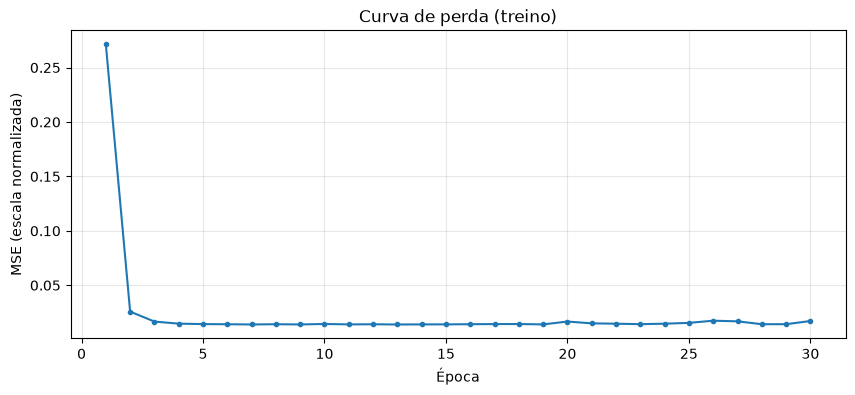

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, epochs + 1), loss_history, marker="o", markersize=3)
plt.title("Curva de perda (treino)")
plt.xlabel("Época")
plt.ylabel("MSE (escala normalizada)")
plt.grid(alpha=0.3)
plt.show()

## 4. Avaliação no conjunto de teste

In [7]:
metrics = evaluate(model, test_loader, device)
print(
    f"MSE: {metrics['mse']:.6f} | RMSE: {metrics['rmse']:.6f} | "
    f"MAE: {metrics['mae']:.6f} (escala normalizada)"
)

MSE: 0.005550 | RMSE: 0.074502 | MAE: 0.066062 (escala normalizada)


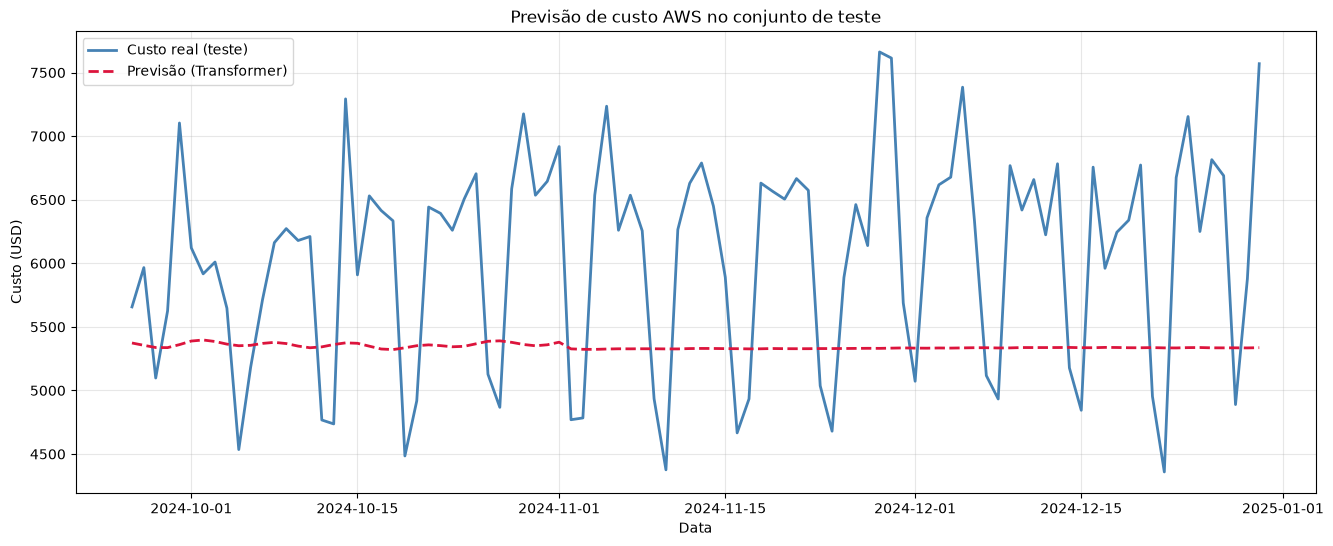

In [8]:
predictions, actuals = collect_predictions(model, test_loader, device)
predictions_original = scaler.inverse_transform(predictions)
actuals_original = scaler.inverse_transform(actuals)

test_dates = df["date"].iloc[cutoff + input_window :].reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(
    test_dates, actuals_original, label="Custo real (teste)", color="steelblue", linewidth=2
)
plt.plot(
    test_dates,
    predictions_original,
    label="Previsão (Transformer)",
    color="crimson",
    linestyle="--",
    linewidth=2,
)
plt.title("Previsão de custo AWS no conjunto de teste")
plt.xlabel("Data")
plt.ylabel("Custo (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Conclusão

O modelo aprende os padrões sazonais (semanal/mensal) e a tendência da série sintética, com erro decrescente ao longo do treino. Os mesmos módulos (`data`, `model`, `training`) são reutilizados pela API de inferência (`src/aws_cost_forecast/api/main.py`), que expõe o modelo treinado via endpoint `/forecast`.